# 05 - Monto potencial y dimensionamiento del negocio

Este es el notebook que junta todo lo anterior en el resultado final. Responde dos
preguntas, en dos partes:

**Parte A — ¿Cuánto invertiría cada cliente?** Entrenamos un modelo de regresión con los
clientes que **ya invierten hoy** (tienen Fiducuenta, CDT/Inversión Virtual o Invesbot):
le enseñamos "dado este perfil de cliente, cuánto tiene invertido", y lo aplicamos a
**toda la base** — incluyendo a quienes todavía no invierten — para estimar cuánto
invertiría alguien con un perfil parecido.

**Parte B — Dimensionamiento.** Juntamos el monto potencial (Parte A) con la probabilidad
de adopción (notebook 03) y el grupo/arquetipo (notebook 04) para calcular el tamaño total
de la oportunidad de negocio, y para priorizar qué segmentos atacar primero.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

pd.set_option('display.width', 120)
pd.options.display.float_format = '{:,.2f}'.format

cliente_360 = pd.read_csv('../04_Resultados/cliente_360.csv')
propension = pd.read_csv('../04_Resultados/propension.csv')
clusters = pd.read_csv('../04_Resultados/clusters.csv')

print('Clientes:', len(cliente_360))

Clientes: 859796


## Parte A — Modelo de monto potencial

### 1. Definir el monto actual invertido (lo que el modelo va a aprender a predecir)

Sumamos el saldo de los 3 productos de inversión (Fiducuenta + CDT/Inversión Virtual +
Invesbot) — un cliente puede tener más de uno a la vez. Solo entrenamos con los clientes
que tienen **al menos uno** de estos productos; a los demás no les conocemos ningún monto
real invertido, así que no pueden enseñarle nada al modelo sobre "cuánto".

In [2]:
cliente_360['monto_actual_invertido'] = (
    cliente_360['saldo_fiducuenta'] +
    cliente_360['saldo_cdt_inv_virtual'] +
    cliente_360['saldo_invesbot']
)

ya_invierte = (
    cliente_360['tiene_fiducuenta'] |
    cliente_360['tiene_cdt_inv_virtual'] |
    cliente_360['tiene_invesbot']
)

print('Clientes que ya invierten (para entrenar):', ya_invierte.sum())
cliente_360.loc[ya_invierte, 'monto_actual_invertido'].describe()

Clientes que ya invierten (para entrenar): 220391


count         220,391.00
mean       21,663,730.55
std        67,262,881.45
min                 0.00
25%            17,264.08
50%         2,015,287.63
75%        17,617,547.57
max     5,400,000,000.00
Name: monto_actual_invertido, dtype: float64

### 2. Elegir las variables (features)

Igual que en el notebook 03: usamos el perfil general del cliente (demografía, ingreso,
patrimonio, productos transaccionales) — **sin usar los saldos ni la tenencia de los
productos de inversión como insumo**, porque son la base del número que queremos predecir
(sería trampa, otra vez *data leakage*). La idea es "con lo que sabemos del cliente aparte
de sus inversiones actuales, ¿cuánto se parece a alguien que invierte mucho o poco?".

In [3]:
columnas_categoricas = ['grupo_edad', 'desc_genero', 'desc_segmento', 'desc_tipo_de_vivienda']

columnas_numericas = [
    'ingresos_mensuales', 'total_egresos_mensuales', 'total_activos',
    'total_pasivos', 'total_patrimonio', 'saldo_aho_cte', 'saldo_bolsillos',
    'estimador_ingreso',
]

columnas_si_no = ['tiene_aho_cte', 'tiene_bolsillos']

datos_modelo = cliente_360[columnas_categoricas + columnas_numericas + columnas_si_no].copy()

datos_modelo['tiene_estimador_ingreso'] = datos_modelo['estimador_ingreso'].notna().astype(int)
mediana_estimador = datos_modelo['estimador_ingreso'].median()
datos_modelo['estimador_ingreso'] = datos_modelo['estimador_ingreso'].fillna(mediana_estimador)

X = pd.get_dummies(datos_modelo, columns=columnas_categoricas, drop_first=True)
print('Columnas del modelo:', X.shape[1])

Columnas del modelo: 24


### Comprimir las variables de entrada que son dinero

En el notebook 04 aplicamos logaritmo al **resultado** que queríamos agrupar. Aquí hay que
hacer algo parecido pero a las **variables de entrada**: `total_patrimonio` y las demás
variables de dinero todavía tienen los mismos valores extremos que vimos en el notebook 00
(hasta 9 billones de pesos) — ahí no los quitamos porque, en general, el patrimonio sí
puede ser alto para un cliente real.

El riesgo es distinto al de k-means: una regresión lineal no tiene ningún límite natural —
si a un cliente le toca un valor de patrimonio extremo, el modelo lo multiplica por su
coeficiente sin ningún freno, y el resultado se puede disparar a números absurdos (esto es
justo lo que pasó en el primer intento de este notebook). Aplicamos logaritmo (con signo,
para respetar los valores negativos) a todas las variables de dinero, para que ningún
valor extremo pueda "disparar" la predicción.


In [4]:
def log_con_signo(serie):
    return np.sign(serie) * np.log1p(serie.abs())

for columna in columnas_numericas:
    X[columna] = log_con_signo(X[columna])

X[columnas_numericas].describe()

,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,saldo_aho_cte,saldo_bolsillos,estimador_ingreso
count,"859,796.00","859,796.00","859,796.00","859,796.00","859,796.00","859,796.00","859,796.00","859,796.00"
mean,14.52,10.99,14.52,3.76,12.87,6.48,2.01,14.88
std,1.85,4.92,5.70,6.69,7.15,6.84,4.70,0.61
min,0.00,0.00,0.00,0.00,-29.83,-16.51,0.00,11.11
25%,14.08,11.51,13.95,0.00,11.94,0.00,0.00,14.45
50%,14.51,12.90,16.20,0.00,15.76,4.39,0.00,14.66
75%,15.40,13.59,18.02,0.69,17.67,13.82,0.00,15.37
max,20.72,20.72,29.83,29.83,29.83,21.53,21.44,19.52


### 3. Transformar el monto a logaritmo

Como vimos en el notebook 04, el dinero tiene una distribución muy despareja — unos pocos
clientes invierten miles de millones, la mayoría invierte mucho menos. Si entrenamos la
regresión con el monto tal cual, esos pocos casos grandes dominan por completo el
aprendizaje. Usamos logaritmo para el entrenamiento, y al final destransformamos
(operación inversa) para volver a pesos.

In [5]:
target_log = np.log1p(cliente_360.loc[ya_invierte, 'monto_actual_invertido'])
X_invierte = X[ya_invierte]

X_train, X_test, y_train, y_test = train_test_split(
    X_invierte, target_log, test_size=0.25, random_state=42
)

print('Clientes en entrenamiento:', len(X_train))
print('Clientes en prueba:', len(X_test))

Clientes en entrenamiento: 165293
Clientes en prueba: 55098


### 4. Escalar, entrenar y evaluar

Igual que en el notebook 03: ajustamos la escala solo con entrenamiento, y usamos un
modelo simple e interpretable — **regresión lineal** (el equivalente de la regresión
logística, pero para predecir un número en vez de una probabilidad).

In [6]:
escalador = StandardScaler()

X_train_escalado = X_train.copy()
X_test_escalado = X_test.copy()
X_train_escalado[columnas_numericas] = escalador.fit_transform(X_train[columnas_numericas])
X_test_escalado[columnas_numericas] = escalador.transform(X_test[columnas_numericas])

modelo_monto = LinearRegression()
modelo_monto.fit(X_train_escalado, y_train)

predicciones_log = modelo_monto.predict(X_test_escalado)

print('R2 (que tanto explica el modelo, 0=nada, 1=perfecto):', r2_score(y_test, predicciones_log))
print('Error promedio, en escala logaritmica:', mean_absolute_error(y_test, predicciones_log))

# tambien en pesos reales, para que sea mas facil de interpretar
error_en_pesos = mean_absolute_error(np.expm1(y_test), np.expm1(predicciones_log))
print(f'Error promedio, en pesos: ${error_en_pesos:,.0f}')

R2 (que tanto explica el modelo, 0=nada, 1=perfecto): 0.1815677304632296
Error promedio, en escala logaritmica: 3.1155401045228155
Error promedio, en pesos: $20,391,076


**Interpretación de los resultados:**

El **R² sale relativamente bajo** (bastante lejos de 1) — esto es esperable, no un error:
se está tratando de estimar un número muy específico (cuántos pesos exactos invierte
alguien) usando solo su perfil general (ingreso, patrimonio, edad, segmento). Hay mucha
variación de persona a persona que ningún dato disponible puede explicar — dos clientes
con el mismo ingreso y patrimonio pueden invertir montos muy distintos por razones que no
están en los datos (su nivel de aversión al riesgo, sus metas personales, etc.).

Esto no invalida el resultado para el uso que se le da: no se necesita acertar el monto
exacto de cada cliente uno por uno — se necesita que, **sumado sobre miles de clientes**,
las sobreestimaciones y subestimaciones se compensen razonablemente, para que el total
agregado (Parte B) sea una referencia útil del tamaño de la oportunidad. Es la misma
lógica de una encuesta de intención de compra: cada respuesta individual puede fallar,
pero el promedio sobre muchas respuestas sigue siendo informativo.

### 5. Calcular el monto potencial para TODOS los clientes

Aplicamos el modelo a toda la base (incluyendo a quienes no invierten hoy), y
destransformamos el resultado de logaritmo a pesos.

In [7]:
X_escalado_completo = X.copy()
X_escalado_completo[columnas_numericas] = escalador.transform(X[columnas_numericas])

monto_log_estimado = modelo_monto.predict(X_escalado_completo)
cliente_360['monto_potencial_estimado'] = np.expm1(monto_log_estimado)

# no tiene sentido un monto potencial negativo, ni por encima de lo que hemos
# observado en la realidad (el maximo que un cliente invierte hoy es ~5.400 millones) -
# un techo de sentido comun, por seguridad, incluso despues de comprimir con logaritmo
techo_realista = cliente_360.loc[ya_invierte, 'monto_actual_invertido'].max()
cliente_360['monto_potencial_estimado'] = cliente_360['monto_potencial_estimado'].clip(
    lower=0, upper=techo_realista
)

cliente_360[['numero_id', 'monto_actual_invertido', 'monto_potencial_estimado']].head(10)

,numero_id,monto_actual_invertido,monto_potencial_estimado
0,8805210490649048784,0.00,"15,531,984.34"
1,-5723572980375902369,0.00,"7,743,374.64"
2,-8245474570363424359,"450,267,852.65","22,635,012.02"
3,-7840506796880772723,0.00,"29,490,418.13"
4,5309731180094827430,0.00,"3,109,929.22"
5,4168144900093410530,"1,100,000,000.00","18,377,185.17"
6,-7937427013897358925,0.00,"21,389,135.02"
7,1773565025055700010,0.00,"1,853,109.86"
8,6379022577202925640,0.00,"2,623,084.39"
9,-4884750236635824483,0.00,"16,200,320.01"


## Parte B — Dimensionamiento del negocio

### 6. Juntar todo: probabilidad + monto + grupo

In [8]:
resultado_final = cliente_360[[
    'numero_id', 'desc_segmento', 'grupo_edad', 'monto_potencial_estimado'
]].merge(propension, on='numero_id').merge(clusters, on='numero_id')

# el valor esperado por cliente es la combinacion de que tan probable es que adopte
# y cuanto invertiria si lo hace
resultado_final['valor_esperado'] = (
    resultado_final['probabilidad_adopcion'] * resultado_final['monto_potencial_estimado']
)

resultado_final.head()

,numero_id,desc_segmento,grupo_edad,monto_potencial_estimado,probabilidad_adopcion,cluster,nombre_cluster,valor_esperado
0,8805210490649048784,preferencial,65+,"15,531,984.34",0.00,0,Base consolidada con patrimonio,"47,527.69"
1,-5723572980375902369,preferencial,50-65,"7,743,374.64",0.01,0,Base consolidada con patrimonio,"48,255.20"
2,-8245474570363424359,preferencial,65+,"22,635,012.02",0.01,0,Base consolidada con patrimonio,"207,301.84"
3,-7840506796880772723,preferencial,65+,"29,490,418.13",0.00,3,Clientes en construccion de patrimonio,"44,310.11"
4,5309731180094827430,preferencial,36-49,"3,109,929.22",0.00,0,Base consolidada con patrimonio,"12,688.51"


### 7. Tamaño total de la oportunidad

Sumamos la probabilidad de cada cliente para estimar cuántos clientes esperamos que
adopten, y sumamos el valor esperado de todos para estimar el volumen total de recursos
que podría canalizarse a través de la App en los próximos 12 meses.

In [9]:
clientes_esperados = resultado_final['probabilidad_adopcion'].sum()
volumen_esperado = resultado_final['valor_esperado'].sum()

print(f'Clientes esperados que adoptarian la App: {clientes_esperados:,.0f}')
print(f'Volumen de inversion esperado (12 meses): ${volumen_esperado:,.0f}')

Clientes esperados que adoptarian la App: 210,862
Volumen de inversion esperado (12 meses): $511,600,678,289


### 8. ¿Qué segmentos priorizar primero?

Desglosamos el volumen esperado por segmento comercial y por grupo/arquetipo, para ver
dónde está concentrada la oportunidad.

In [10]:
por_segmento = resultado_final.groupby('desc_segmento').agg(
    clientes_esperados=('probabilidad_adopcion', 'sum'),
    volumen_esperado=('valor_esperado', 'sum'),
).sort_values('volumen_esperado', ascending=False)

por_segmento

,clientes_esperados,volumen_esperado
desc_segmento,,
preferencial,"14,802.51","295,211,715,097.32"
plus,"106,704.90","147,724,127,527.21"
personal,"89,355.01","68,664,835,664.14"


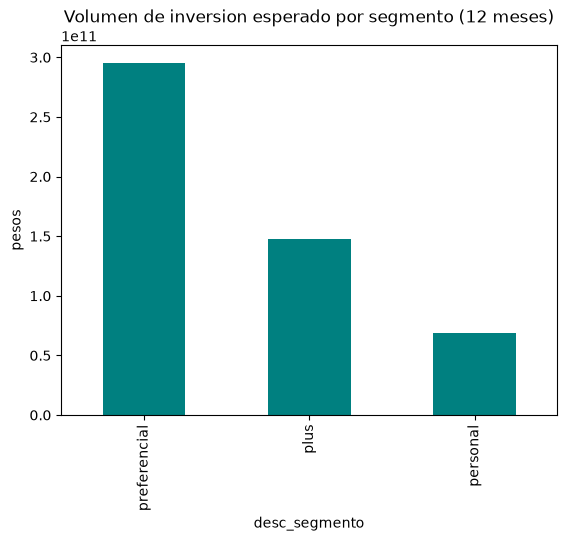

In [11]:
por_segmento['volumen_esperado'].plot(
    kind='bar', title='Volumen de inversion esperado por segmento (12 meses)', color='teal'
)
plt.ylabel('pesos')
plt.show()

In [12]:
por_grupo = resultado_final.groupby('nombre_cluster').agg(
    clientes_esperados=('probabilidad_adopcion', 'sum'),
    volumen_esperado=('valor_esperado', 'sum'),
).sort_values('volumen_esperado', ascending=False)

por_grupo

,clientes_esperados,volumen_esperado
nombre_cluster,,
Base consolidada con patrimonio,"167,913.73","445,920,990,843.51"
Clientes en construccion de patrimonio,"25,007.00","49,416,924,105.25"
Jovenes en etapa inicial,"17,549.50","13,464,633,479.13"
Clientes sin huella financiera visible,373.49,"2,028,699,661.16"
Patrimonio atipico (revisar aparte),18.71,"769,430,199.64"


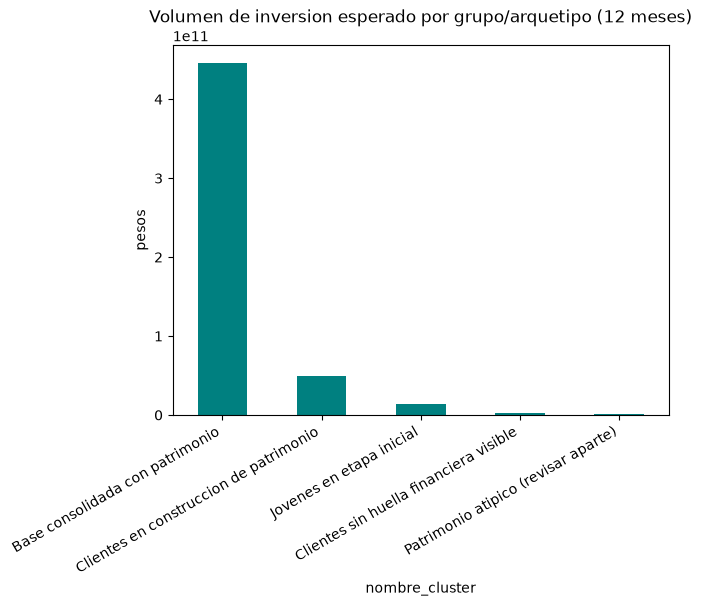

In [13]:
por_grupo['volumen_esperado'].plot(
    kind='bar', title='Volumen de inversion esperado por grupo/arquetipo (12 meses)', color='teal'
)
plt.ylabel('pesos')
plt.xticks(rotation=30, ha='right')
plt.show()

### 9. Los clientes más prioritarios

Una muestra de los clientes con mayor valor esperado — la lista que, en la práctica, se le
entregaría al equipo comercial para priorizar el contacto.

In [14]:
resultado_final.sort_values('valor_esperado', ascending=False).head(20)

,numero_id,desc_segmento,grupo_edad,monto_potencial_estimado,probabilidad_adopcion,cluster,nombre_cluster,valor_esperado
4334,-791934323730940050,preferencial,65+,"688,125,023.79",0.99,-1,Patrimonio atipico (revisar aparte),"684,042,089.83"
302,-6959371955017251731,preferencial,65+,"711,182,576.76",0.78,1,Clientes sin huella financiera visible,"553,838,812.10"
2910,2458453958124839634,preferencial,65+,"507,594,041.39",1.00,0,Base consolidada con patrimonio,"507,594,001.96"
4000,7034526716302035950,preferencial,65+,"440,248,754.04",1.00,0,Base consolidada con patrimonio,"440,247,172.33"
831786,-2211535306391327693,preferencial,65+,"438,002,170.57",1.00,0,Base consolidada con patrimonio,"437,963,465.64"
1240,529823479059254472,preferencial,65+,"582,424,241.75",0.72,0,Base consolidada con patrimonio,"420,439,581.82"
4926,-5867538549206379207,preferencial,65+,"411,762,786.64",1.00,0,Base consolidada con patrimonio,"410,476,360.05"
4437,-3486009181075000159,preferencial,65+,"401,009,695.49",0.98,0,Base consolidada con patrimonio,"392,572,621.99"
3848,-4809871807261063518,preferencial,65+,"403,813,474.21",0.95,3,Clientes en construccion de patrimonio,"385,093,756.60"
2400,4307662175769706183,preferencial,65+,"388,122,917.71",0.95,3,Clientes en construccion de patrimonio,"370,512,944.70"


## 10. Guardar el resultado final

Esta es la tabla que consume el tablero (`05_Tablero/app.py`).

In [15]:
resultado_final.to_csv('../04_Resultados/scoring_final.csv', index=False)
print('Guardado:', len(resultado_final), 'clientes en el resultado final')

Guardado: 859796 clientes en el resultado final
